In [4]:
library(readxl)
library(writexl)
library(ggplot2)
library(dplyr)
library(ggExtra)
library(anthroplus)
library(scales)
library(knitr)
library(officer)
library(flextable)
library(janitor)
library(tidyr)

# source('fungsi/bmi_calc.R')
source('fungsi/bmi_calc2.R')
source('fungsi/summary.R')

In [5]:
female_data <- read_excel("raw_data/female_data.xlsx")
female_data

# A tibble: 1,010 × 8
   ks    tl                   umur sex      tb    bb    bf   bmi
   <chr> <dttm>              <dbl> <chr> <dbl> <dbl> <dbl> <dbl>
 1 SM715 2012-10-16 00:00:00  12.9 F      141   36.2  11.4  18.2
 2 SM716 2012-06-29 00:00:00  13.3 F      158.  45.1  13.3  18  
 3 SM717 2013-03-19 00:00:00  12.5 F      142.  43.7  26.2  21.8
 4 SM718 2012-12-14 00:00:00  12.8 F      148   55.4  71.1  25.3
 5 SM719 2013-02-20 00:00:00  12.6 F      128   38.5  24.2  23.5
 6 SM720 2012-12-16 00:00:00  12.8 F      146   43.6  23    20.5
 7 SM721 2013-01-22 00:00:00  12.7 F      155   38.8  15    16  
 8 SM722 2010-09-12 00:00:00  15   F      162   47    21.4  17.9
 9 SM723 2012-11-10 00:00:00  12.8 F      150   35.5   7.1  15.8
10 SM724 2012-12-19 00:00:00  12.8 F      135   32    13.5  17.5
# ℹ 1,000 more rows
# ℹ Use `print(n = ...)` to see more rows

# A. Analisis Status Gizi Menggunakan `anthropolus`
### 1. Menyiapkan Data

In [5]:
female_data_clean <- female_data %>%
  filter(
    !is.na(bb),
    !is.na(tb),
    !is.na(umur)
  ) %>%
  mutate(
    bb = as.numeric(bb),
    tb = as.numeric(tb),

    # age (years -> months)
    umur_bulan = as.numeric(umur) * 12,

    # BMI
    bmi = bb / (tb/100)^2
  )

# Raw data > Remove missing values > Convert age to months > Calculate BMI

### 2. Menghitung z-scores WHO BMI-for-age

In [4]:
who_results <- anthroplus_zscores(
  sex = rep(2, nrow(female_data_clean)),
  age_in_months = female_data_clean$umur_bulan,
  height_in_cm = female_data_clean$tb,
  weight_in_kg = female_data_clean$bb
)
# Age
# Height
# Weight
#      ↓
# WHO LMS reference
#      ↓
# WHO BMI-for-age z-score

### 3. Mengkategorikan Status Gizi

In [5]:
female_data_final <- female_data_clean %>%
  mutate(
    bmi_zscore_who = who_results$zbfa
  ) %>%
  mutate(
    bmi_category_who = case_when(

      bmi_zscore_who < -3 ~
        "Gizi Buruk",

      bmi_zscore_who >= -3 &
        bmi_zscore_who < -2 ~
        "Gizi Kurang",

      bmi_zscore_who >= -2 &
        bmi_zscore_who <= 1 ~
        "Gizi Normal",

      bmi_zscore_who > 1 &
        bmi_zscore_who <= 2 ~
        "Gizi Lebih",

      bmi_zscore_who > 2 ~
        "Obesitas"
    ),

    bmi_category_who = factor(
      bmi_category_who,
      levels = c(
        "Gizi Buruk",
        "Gizi Kurang",
        "Gizi Normal",
        "Gizi Lebih",
        "Obesitas"
      )
    )
  )
# WHO z-score
    #  ↓
# WHO cutoff
    #  ↓
# Nutritional status
female_data_final

# A tibble: 1,010 × 11
   ks    tl                   umur sex      tb    bb    bf   bmi umur_bulan bmi_zscore_who bmi_category_who
   <chr> <dttm>              <dbl> <chr> <dbl> <dbl> <dbl> <dbl>      <dbl>          <dbl> <fct>           
 1 SM715 2012-10-16 00:00:00  12.9 F      141   36.2  11.4  18.2       155.          -0.21 Gizi Normal     
 2 SM716 2012-06-29 00:00:00  13.3 F      158.  45.1  13.3  18.0       160.          -0.45 Gizi Normal     
 3 SM717 2013-03-19 00:00:00  12.5 F      142.  43.7  26.2  21.8       150            1.15 Gizi Lebih      
 4 SM718 2012-12-14 00:00:00  12.8 F      148   55.4  71.1  25.3       154.           1.87 Gizi Lebih      
 5 SM719 2013-02-20 00:00:00  12.6 F      128   38.5  24.2  23.5       151.           1.54 Gizi Lebih      
 6 SM720 2012-12-16 00:00:00  12.8 F      146   43.6  23    20.5       154.           0.65 Gizi Normal     
 7 SM721 2013-01-22 00:00:00  12.7 F      155   38.8  15    16.1       152.          -1.15 Gizi Normal     
 8 SM

---

# B. Validasi
### 1. Mengekstrak Nilai LMS WHO

In [6]:
who_lms <- anthroplus:::bfa_growth_standards %>%
  filter(sex == 2) %>%
  select(age, l, m, s)

# WHO reference table
    #  ↓
# Age
# L
# M
# S

### 2. Menyimpan Nilai LMS

In [7]:
female_validation <- female_data_clean %>%
  mutate(
    age_months_who = round(umur_bulan)
  ) %>%
  left_join(
    who_lms,
    by = c("age_months_who" = "age")
  )

# Participant
#  +
# WHO LMS row
#  ↓
# Participant-specific
# L M S

### 3. Menghitung Z-Score secara Manual

In [8]:
female_validation <- female_validation %>%
  mutate(

    bmi_z_manual = ifelse(

      l == 0,

      log(bmi / m) / s,

      (((bmi / m)^l) - 1) /
        (l * s)

    )

  )

### 4. Menghitung Z-Scores dari Paket

In [9]:
who_pkg <- anthroplus_zscores(
  sex = rep(2, nrow(female_validation)),
  age_in_months = female_validation$umur_bulan,
  height_in_cm = female_validation$tb,
  weight_in_kg = female_validation$bb
)

female_validation$bmi_z_package <-
  who_pkg$zbfa

# anthroplus
#      ↓
# WHO z-score

In [10]:
female_validation

# A tibble: 1,010 × 15
   ks    tl                   umur sex      tb    bb    bf   bmi umur_bulan age_months_who     l     m     s bmi_z_manual bmi_z_package
   <chr> <dttm>              <dbl> <chr> <dbl> <dbl> <dbl> <dbl>      <dbl>          <dbl> <dbl> <dbl> <dbl>        <dbl>         <dbl>
 1 SM715 2012-10-16 00:00:00  12.9 F      141   36.2  11.4  18.2       155.            155 -1.33  18.7 0.134       -0.216         -0.21
 2 SM716 2012-06-29 00:00:00  13.3 F      158.  45.1  13.3  18.0       160.            160 -1.29  19.1 0.135       -0.462         -0.45
 3 SM717 2013-03-19 00:00:00  12.5 F      142.  43.7  26.2  21.8       150             150 -1.36  18.4 0.133        1.15           1.15
 4 SM718 2012-12-14 00:00:00  12.8 F      148   55.4  71.1  25.3       154.            154 -1.33  18.7 0.134        1.86           1.87
 5 SM719 2013-02-20 00:00:00  12.6 F      128   38.5  24.2  23.5       151.            151 -1.36  18.5 0.133        1.54           1.54
 6 SM720 2012-12-16 00:00

---
## PERHITUNGAN Z-SCORE 3 METODE: MANUAL, INTERPOLASI DAN PAKET anthropolus

In [23]:
# menghitung z-scores dan kategori
female_results <- calculate_bmi_zscores(female_data, target_sex=2)

In [24]:
female_results


# A tibble: 1,010 × 18
   ks    tl                   umur sex      tb    bb    bf bmi_empiris
   <chr> <dttm>              <dbl> <chr> <dbl> <dbl> <dbl>       <dbl>
 1 SM715 2012-10-16 00:00:00  12.9 F      141   36.2  11.4        18.2
 2 SM716 2012-06-29 00:00:00  13.3 F      158.  45.1  13.3        18  
 3 SM717 2013-03-19 00:00:00  12.5 F      142.  43.7  26.2        21.8
 4 SM718 2012-12-14 00:00:00  12.8 F      148   55.4  71.1        25.3
 5 SM719 2013-02-20 00:00:00  12.6 F      128   38.5  24.2        23.5
 6 SM720 2012-12-16 00:00:00  12.8 F      146   43.6  23          20.5
 7 SM721 2013-01-22 00:00:00  12.7 F      155   38.8  15          16  
 8 SM722 2010-09-12 00:00:00  15   F      162   47    21.4        17.9
 9 SM723 2012-11-10 00:00:00  12.8 F      150   35.5   7.1        15.8
10 SM724 2012-12-19 00:00:00  12.8 F      135   32    13.5        17.5
# ℹ 1,000 more rows
# ℹ 10 more variables: umur_bulan <dbl>, bmi_who <dbl>, bmi_z_manual <dbl>,
#   bmi_z_interp <dbl>, bmi_z

In [25]:
summarize_categorical(female_results, "cat_package")

# A tibble: 6 × 3
  Category     Freq Percentage
  <chr>       <int>      <dbl>
1 Gizi Buruk      4        0.4
2 Gizi Kurang    70        6.9
3 Gizi Normal   729       72.2
4 Gizi Lebih    144       14.3
5 Obesitas       63        6.2
6 Total        1010      100  

In [26]:
summarize_categorical(female_results, "cat_manual")

# A tibble: 6 × 3
  Category     Freq Percentage
  <chr>       <int>      <dbl>
1 Gizi Buruk      4        0.4
2 Gizi Kurang    71        7  
3 Gizi Normal   726       71.9
4 Gizi Lebih    146       14.5
5 Obesitas       63        6.2
6 Total        1010      100  

In [27]:
summarize_categorical(female_results, "cat_interp")

# A tibble: 6 × 3
  Category     Freq Percentage
  <chr>       <int>      <dbl>
1 Gizi Buruk      4        0.4
2 Gizi Kurang    71        7  
3 Gizi Normal   726       71.9
4 Gizi Lebih    146       14.5
5 Obesitas       63        6.2
6 Total        1010      100  

In [29]:
write_xlsx(female_results, "female_nutritional_status.xlsx")

In [30]:
perbedaan_cat <- female_results %>%
  filter(cat_manual != cat_package | cat_package != cat_interp) %>%
  select(ks, umur_bulan, bmi_empiris, bmi_z_manual, bmi_z_interp, bmi_z_package, cat_manual, cat_package, cat_interp)

# Tampilkan hasil ke konsol R
perbedaan_cat

# A tibble: 3 × 9
  ks     umur_bulan bmi_empiris bmi_z_manual bmi_z_interp bmi_z_package
  <chr>       <dbl>       <dbl>        <dbl>        <dbl>         <dbl>
1 AA723        146.        21           1.01         1.00             1
2 NM1116       198         16.3        -2.00        -2.00            -2
3 SF1031       180         23.5         1.00         1.00             1
# ℹ 3 more variables: cat_manual <ord>, cat_package <ord>, cat_interp <ord>

In [31]:
summarize_continuous(female_results, "bmi_z_package")

# A tibble: 5 × 2
  Statistic    Value                 
  <chr>        <chr>                 
1 N            1010                  
2 Mean ± SD    -0.103 ± 1.303        
3 Median (IQR) -0.190 (-1.005, 0.780)
4 Minimum      -3.87                 
5 Maximum      3.99                  

In [10]:
plot_bmi_comprehensive <- function(df, bmi_col) {
  
  if (!requireNamespace("patchwork", quietly = TRUE)) install.packages("patchwork")
  if (!requireNamespace("e1071", quietly = TRUE)) install.packages("e1071")
  
  library(ggplot2)
  library(patchwork)
  library(e1071)
  
  # ==========================================
  # 1. Statistik & Preparasi Data
  # ==========================================
  x <- df[[bmi_col]][!is.na(df[[bmi_col]])]
  
  m_mean   <- mean(x)
  m_median <- median(x)
  m_sd     <- sd(x)
  m_skew   <- skewness(x)
  
  x_min <- min(x)
  x_max <- max(x)
  
  # Densitas untuk Kurva Normal
  x_range <- seq(x_min, x_max, length.out = 500)
  y_norm  <- dnorm(x_range, mean = m_mean, sd = m_sd)
  df_norm <- data.frame(x = x_range, y = y_norm)
  shade_sd <- subset(df_norm, x >= (m_mean - m_sd) & x <= (m_mean + m_sd))
  
  # Sinkronisasi sumbu Y
  dens <- density(x)
  y_max <- max(max(dens$y), max(y_norm)) * 1.15 
  
  # ==========================================
  # 2. LOGIKA ANOTASI SKEWNESS OTOMATIS (ENGLISH)
  # ==========================================
  is_right_skew <- m_skew > 0
  
  skew_label <- ifelse(is_right_skew, 
                       "Right-Skewed\n(Positive Tail)", 
                       "Left-Skewed\n(Negative Tail)")
  
  # Penempatan teks (30% dari ujung ekor)
  text_x <- ifelse(is_right_skew, 
                   x_max - (x_max - m_mean) * 0.3, 
                   x_min + (m_mean - x_min) * 0.3)
  text_y <- y_max * 0.5 # Tinggi teks
  
  # Ujung panah menunjuk ke 10% area paling ekstrem
  arrow_x <- ifelse(is_right_skew, 
                    x_max - (x_max - m_mean) * 0.1, 
                    x_min + (m_mean - x_min) * 0.1)
  arrow_y <- y_max * 0.05 
  
  # ==========================================
  # 3. PLOT KIRI: Empiris 
  # ==========================================
  p1 <- ggplot(df, aes(x = .data[[bmi_col]])) +
    geom_histogram(
      aes(y = after_stat(density)), 
      binwidth = 0.5, boundary = 0, fill = "#A8B8C6", color = "white", alpha = 0.5, na.rm = TRUE
    ) +
    geom_density(aes(color = "Empirical Density"), linewidth = 1.2, key_glyph = "path", na.rm = TRUE) +
    geom_vline(aes(xintercept = m_mean, color = "Mean"), linewidth = 1.2, linetype = "solid") +
    geom_vline(aes(xintercept = m_median, color = "Median"), linewidth = 1.2, linetype = "solid") +
    
    # Anotasi Teks Otomatis
    annotate(
      "text", x = text_x, y = text_y, label = skew_label, 
      color = "#5c5c5c", fontface = "bold", size = 4
    ) +
    
    # Panah Dinamis
    annotate(
      "curve", x = text_x, y = text_y - (y_max * 0.03), xend = arrow_x, yend = arrow_y,
      curvature = ifelse(is_right_skew, 0.3, -0.3), 
      arrow = arrow(length = unit(0.25, "cm"), type = "closed"), 
      color = "#5c5c5c", linewidth = 0.8
    ) +
    
    scale_color_manual(values = c("Empirical Density" = "#2F4858", "Mean" = "#336699", "Median" = "#CC6600")) +
    coord_cartesian(xlim = c(x_min, x_max), ylim = c(0, y_max)) +
    labs(
      title = "Empirical Distribution",
      subtitle = sprintf("Skewness: %.3f | Central Tendency", m_skew),
      x = expression(Z-Score~BMI), y = "Density"
    ) +
    theme_classic(base_size = 13) +
    theme(legend.position = "bottom", legend.title = element_blank())
    
  # ==========================================
  # 4. PLOT KANAN: Normal Teoretis
  # ==========================================
  p2 <- ggplot(df_norm, aes(x = x, y = y)) +
    geom_area(data = shade_sd, aes(x = x, y = y, fill = "±1 SD (68.3%)"), alpha = 0.3) +
    geom_line(aes(color = "Normal Curve"), linewidth = 1.2) +
    geom_vline(xintercept = c(m_mean - m_sd, m_mean + m_sd), color = "#D1495B", linetype = "dashed", linewidth = 0.8) +
    geom_vline(aes(xintercept = m_mean, color = "Mean (Center)"), linewidth = 1.2) +
    
    scale_color_manual(values = c("Normal Curve" = "#D1495B", "Mean (Center)" = "#336699")) +
    scale_fill_manual(values = c("±1 SD (68.3%)" = "#D1495B")) +
    coord_cartesian(xlim = c(x_min, x_max), ylim = c(0, y_max)) +
    labs(
      title = "Theoretical Normal Model",
      subtitle = sprintf("SD: %.2f | Expected Variance", m_sd),
      x = expression(Z-Score~BMI), y = "" 
    ) +
    theme_classic(base_size = 13) +
    theme(
      legend.position = "bottom", 
      legend.title = element_blank(),
      axis.text.y = element_blank(), 
      axis.ticks.y = element_blank(),
      axis.line.y = element_blank()
    )

  # ==========================================
  # 5. PENGGABUNGAN 
  # ==========================================
  final_plot <- p1 + p2 + 
    plot_annotation(
      # title = "BMI Distribution Audit: Empirical vs. Theoretical Expectation",
      theme = theme(plot.title = element_text(face = "bold", hjust = 0.5, size = 16))
    )
    
  return(final_plot)
}


Attaching package: ‘e1071’

The following object is masked from ‘package:ggplot2’:

    element



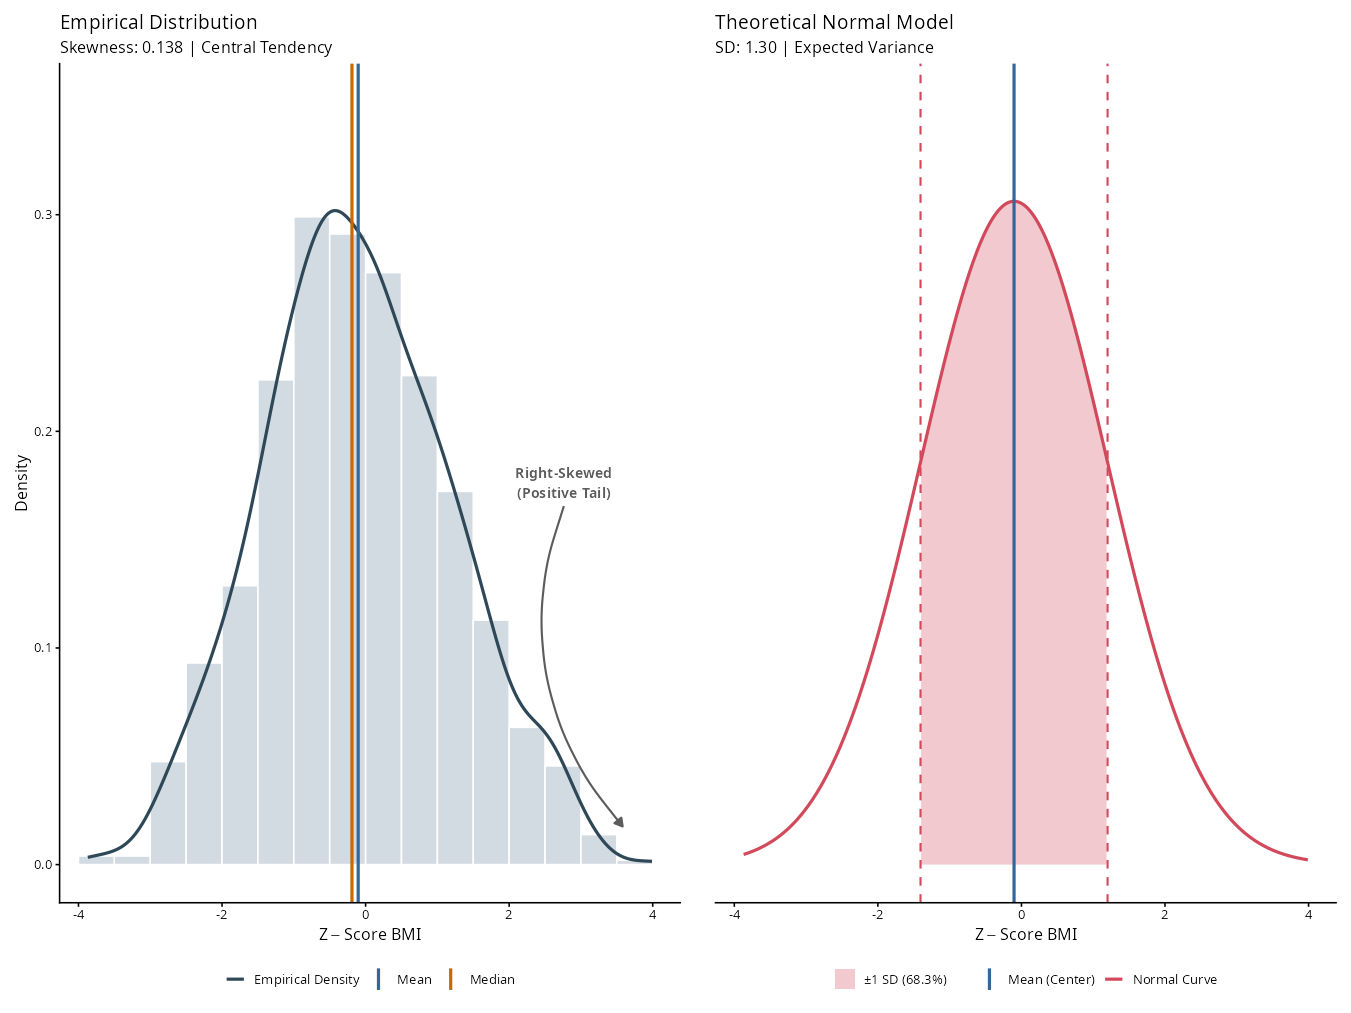

In [11]:
female_bmi_density <- plot_bmi_comprehensive(df=comparison_full, bmi_col = "bmi_z_package")
female_bmi_density

In [12]:
ggsave("plot/female_density_curve.png", female_bmi_density, width = 10, height = 8, units = "in", dpi=1200)

In [37]:
generate_who_charts <- function(data, 
                                category_col, 
                                bmi_col = "bmi_empiris", 
                                age_col = "umur_bulan", 
                                target_sex = 1) {
  
  # =====================================================================
  # 1. PENYIAPAN DATA & STANDARISASI KOLOM
  # =====================================================================
  status_levels <- c("Gizi Buruk", "Gizi Kurang", "Gizi Normal", "Gizi Lebih", "Obesitas")
  
  plot_df <- data %>%
    rename(
      val_bmi = all_of(bmi_col),
      val_age = all_of(age_col)
    ) %>%
    # PERBAIKAN 1: Biarkan NA pada kategori tetap hidup. Hanya buang yang tidak punya koordinat umur/BMI.
    filter(!is.na(val_bmi), !is.na(val_age)) %>%
    # PERBAIKAN 2: Injeksi materialisasi NA dilakukan langsung di data utama, bukan di tabel.
    mutate(
      !!sym(category_col) := factor(.data[[category_col]], levels = status_levels),
      !!sym(category_col) := forcats::fct_na_value_to_level(.data[[category_col]], level = "Tidak Terdefinisi")
    )
  
  who_lms <- anthroplus:::bfa_growth_standards %>%
    filter(sex == target_sex) %>% arrange(age)
  
  who_curves <- who_lms %>%
    mutate(
      z_m3 = m * (1 + l*s*(-3))^(1/l), z_m2 = m * (1 + l*s*(-2))^(1/l),
      z_m1 = m * (1 + l*s*(-1))^(1/l), z_0  = m,
      z_p1 = m * (1 + l*s*(1))^(1/l), z_p2 = m * (1 + l*s*(2))^(1/l),
      z_p3 = m * (1 + l*s*(3))^(1/l)
    )
  
  min_bound <- floor(min(c(plot_df$val_bmi, who_curves$z_m3), na.rm = TRUE)) - 2
  max_bound <- ceiling(max(c(plot_df$val_bmi, who_curves$z_p3), na.rm = TRUE)) + 2
  
  zone_df <- who_curves %>%
    transmute(
      age, zm3 = z_m3, zm2 = z_m2, zp1 = z_p1, zp2 = z_p2,
      ymin = min_bound, ymax = max_bound
    )
  
  # PERBAIKAN 3: Karena plot_df sudah paten, pembuatan cat_table menjadi jauh lebih sederhana
  cat_table <- plot_df %>%
    group_by(.data[[category_col]]) %>%
    summarise(n = n(), .groups = "drop") %>%
    arrange(.data[[category_col]]) %>%
    mutate(pct = round(100 * n / sum(n), 1))
  
  # PERBAIKAN 4: Membuat label legenda HANYA untuk kategori yang valid (membuang label NA dari legenda scatter plot)
  valid_cats <- cat_table %>% filter(.data[[category_col]] != "Tidak Terdefinisi")
  legend_labels <- setNames(
    paste0(valid_cats[[category_col]], " (", valid_cats$pct, "%)"),
    valid_cats[[category_col]]
  )
  
  label_df <- data.frame(
    age = max(who_curves$age) + 3,
    val_bmi = c(
      dplyr::last(who_curves$z_m3), dplyr::last(who_curves$z_m2), dplyr::last(who_curves$z_m1),
      dplyr::last(who_curves$z_0),  dplyr::last(who_curves$z_p1), dplyr::last(who_curves$z_p2),
      dplyr::last(who_curves$z_p3)
    ),
    label = c("-3", "-2", "-1", "0", "+1", "+2", "+3")
  )
  
  who_curves_long <- who_curves %>%
    pivot_longer(cols = starts_with("z_"), names_to = "curve", values_to = "value") %>%
    mutate(curve = factor(curve, levels = c("z_m3", "z_m2", "z_m1", "z_0", "z_p1", "z_p2", "z_p3")))

  # =====================================================================
  # 2. MESIN DETEKSI EKSPLOSI SE MATEMATIS (TWO-TAILED)
  # =====================================================================
  loess_model <- loess(val_bmi ~ val_age, data = plot_df, span = 0.9, 
                       control = loess.control(surface = "direct"))
  
  age_seq <- sort(unique(plot_df$val_age))
  loess_pred <- predict(loess_model, newdata = data.frame(val_age = age_seq), se = TRUE)
  se_values <- loess_pred$se.fit
  
  se_baseline <- median(se_values, na.rm = TRUE)
  se_mad <- mad(se_values, na.rm = TRUE)
  se_threshold <- se_baseline + (3 * se_mad) 
  
  mid_age <- median(age_seq, na.rm = TRUE)
  
  upper_explosion <- age_seq[age_seq > mid_age & se_values > se_threshold]
  dynamic_upper_cutoff <- if (length(upper_explosion) > 0) min(upper_explosion) else max(age_seq, na.rm = TRUE)
  
  lower_explosion <- age_seq[age_seq < mid_age & se_values > se_threshold]
  dynamic_lower_cutoff <- if (length(lower_explosion) > 0) max(lower_explosion) else min(age_seq, na.rm = TRUE)
  
  max_bmi <- max(plot_df$val_bmi, na.rm = TRUE)
  min_bmi <- min(plot_df$val_bmi, na.rm = TRUE)

  # =====================================================================
  # 3. PENGATURAN PLOT
  # =====================================================================
  master_colors <- c(
    "Gizi Buruk" = "#31688e", "Gizi Kurang" = "#639bb4", "Gizi Normal" = "#d9d9d9",
    "Gizi Lebih" = "#e07a5f", "Obesitas" = "#b11226"
  )
  
  shared_layers <- list(
    # PERBAIKAN 5: Filter NA agar tidak menjadi titik (dot) di scatter plot
    geom_point(
      data = plot_df %>% filter(.data[[category_col]] != "Tidak Terdefinisi"), 
      aes(val_age, val_bmi, fill = .data[[category_col]]), 
      shape = 21, color = "white", alpha = 0.8, size = 2.8
    ),
    geom_text(data = label_df, aes(age, val_bmi, label = label), hjust = 0, size = 5),
    
    # PERBAIKAN 6: Paksa legenda hanya memunculkan yang ada di `legend_labels` menggunakan 'breaks'
    scale_fill_manual(
      values = master_colors, 
      labels = legend_labels,
      breaks = names(legend_labels)
    ),
    
    coord_cartesian(xlim = c(125, max(who_curves$age) + 15)),
    scale_x_continuous(expand = expansion(mult = c(0, 0.08))),
    theme_classic(base_size = 16),
    theme(legend.position = "bottom", legend.title = element_blank()),
    labs(subtitle = NULL, x = "Age (months)", y = expression(BMI~(kg/m^2)))
  )
  
  clean_colors <- c("z_m3"="#31688e", "z_m2"="#639bb4", "z_m1"="grey50", "z_0"="grey40", "z_p1"="grey50", "z_p2"="#e07a5f", "z_p3"="#b11226")
  clean_lines  <- c("z_m3"="solid", "z_m2"="solid", "z_m1"="dotted", "z_0"="solid", "z_p1"="dotted", "z_p2"="solid", "z_p3"="solid")
  clean_sizes  <- c("z_m3"=0.7, "z_m2"=0.7, "z_m1"=0.6, "z_0"=1.0, "z_p1"=0.6, "z_p2"=0.7, "z_p3"=0.7)
  
  base_clean_plot <- ggplot() +
    geom_line(data = who_curves_long, aes(age, value, group = curve, color = curve, linetype = curve, linewidth = curve)) +
    scale_color_manual(values = clean_colors) + scale_linetype_manual(values = clean_lines) + scale_linewidth_manual(values = clean_sizes) +
    guides(color = "none", linetype = "none", linewidth = "none") +
    shared_layers

  # --- PLOT 1: FULL LOESS DENGAN ANOTASI DUA SISI ---
  plot_clean_full <- base_clean_plot +
    geom_vline(xintercept = dynamic_upper_cutoff, linetype = "dashed", color = "black", linewidth = 0.8) +
    annotate("segment", x = dynamic_upper_cutoff - 20, xend = dynamic_upper_cutoff - 1, 
             y = max_bmi, yend = max_bmi, 
             arrow = arrow(length = unit(0.2, "cm"), type = "closed"), 
             color = "black", linewidth = 0.6) +
    annotate("text", x = dynamic_upper_cutoff - 22, y = max_bmi, 
             label = sprintf("Upper Cutoff:\nSE > 3 MAD\nat %.1f mo", dynamic_upper_cutoff), 
             hjust = 1, size = 4, fontface = "italic", lineheight = 1.1) +
    geom_vline(xintercept = dynamic_lower_cutoff, linetype = "dashed", color = "black", linewidth = 0.8) +
    annotate("segment", x = dynamic_lower_cutoff + 20, xend = dynamic_lower_cutoff + 1, 
             y = max_bmi - 3, yend = max_bmi - 3, 
             arrow = arrow(length = unit(0.2, "cm"), type = "closed"), 
             color = "black", linewidth = 0.6) +
    annotate("text", x = dynamic_lower_cutoff + 22, y = max_bmi - 3, 
             label = sprintf("Lower Cutoff:\nSE > 3 MAD\nat %.1f mo", dynamic_lower_cutoff), 
             hjust = 0, size = 4, fontface = "italic", lineheight = 1.1) +
    geom_smooth(data = plot_df, aes(val_age, val_bmi), method = "loess", span = 0.9, 
                se = TRUE, fill = "grey60", alpha = 0.4, linewidth = 1.2, color = "black")
  
  # --- PLOT 2: TRIMMED LOESS (Dipotong Kiri dan Kanan) ---
  plot_clean_trimmed <- base_clean_plot +
    geom_smooth(data = plot_df %>% filter(val_age >= dynamic_lower_cutoff & val_age <= dynamic_upper_cutoff), 
                aes(val_age, val_bmi), method = "loess", span = 0.9, 
                se = FALSE, linewidth = 1.2, color = "black")

  # --- PLOT 3: ZONE PLOT ---
  zone_lines <- c("z_m3"="dashed", "z_m2"="dashed", "z_m1"="dotted", "z_0"="solid", "z_p1"="dotted", "z_p2"="dashed", "z_p3"="dashed")
  zone_sizes <- c("z_m3"=0.6, "z_m2"=0.6, "z_m1"=0.6, "z_0"=1.0, "z_p1"=0.6, "z_p2"=0.6, "z_p3"=0.6)
  
  plot_zone <- ggplot() +
    geom_ribbon(data = zone_df, aes(age, ymin = ymin, ymax = zm3), fill = "#31688e", alpha = 0.05) +
    geom_ribbon(data = zone_df, aes(age, ymin = zm3, ymax = zm2), fill = "#639bb4", alpha = 0.05) +
    geom_ribbon(data = zone_df, aes(age, ymin = zm2, ymax = zp1), fill = "#d9d9d9", alpha = 0.08) +
    geom_ribbon(data = zone_df, aes(age, ymin = zp1, ymax = zp2), fill = "#e07a5f", alpha = 0.05) +
    geom_ribbon(data = zone_df, aes(age, ymin = zp2, ymax = ymax), fill = "#b11226", alpha = 0.05) +
    geom_line(data = who_curves_long, aes(age, value, group = curve, linetype = curve, linewidth = curve)) +
    scale_linetype_manual(values = zone_lines) + scale_linewidth_manual(values = zone_sizes) +
    guides(linetype = "none", linewidth = "none") +
    shared_layers +
    geom_smooth(data = plot_df %>% filter(val_age >= dynamic_lower_cutoff & val_age <= dynamic_upper_cutoff), 
                aes(val_age, val_bmi), method = "loess", span = 0.9, se = FALSE, linewidth = 1.2, color = "black") +
    labs(title = "WHO BMI-for-Age Growth Chart")
    
  # --- PLOT 4: BAR PLOT DISTRIBUTION ---
  urutan_asli <- setdiff(as.character(unique(cat_table[[category_col]])), "Tidak Terdefinisi")

  plot_dist <- ggplot(
      data = cat_table %>% filter(.data[[category_col]] != "Tidak Terdefinisi"), 
      aes(x = .data[[category_col]], y = pct, fill = .data[[category_col]])
    ) +
    geom_col(width = 0.7, color = "black", linewidth = 0.25) +
    geom_text(aes(label = sprintf("%.1f%%", pct)), vjust = -0.5, size = 5, fontface = "bold") +
    scale_fill_manual(values = master_colors) +
    scale_x_discrete(limits = urutan_asli) +
    scale_y_continuous(labels = scales::label_percent(scale = 1), expand = expansion(mult = c(0, 0.15))) +
    theme_minimal(base_size = 18) +
    theme(
      legend.position = "none",
      panel.grid.major.x = element_blank(),
      panel.grid.minor = element_blank(),
      axis.text = element_text(color = "black"),
      axis.line.y = element_line(color = "black", linewidth = 0.5)
    ) +
    labs(title = NULL, x = NULL, y = "Percentage (%)")
  
  # =====================================================================
  # 4. EXPORT HASIL
  # =====================================================================
  list(
    clean_plot_full = plot_clean_full, 
    clean_plot_trimmed = plot_clean_trimmed, 
    zone_plot = plot_zone, 
    bar_plot = plot_dist,
    calculated_upper_cutoff = dynamic_upper_cutoff,
    calculated_lower_cutoff = dynamic_lower_cutoff
  )
}

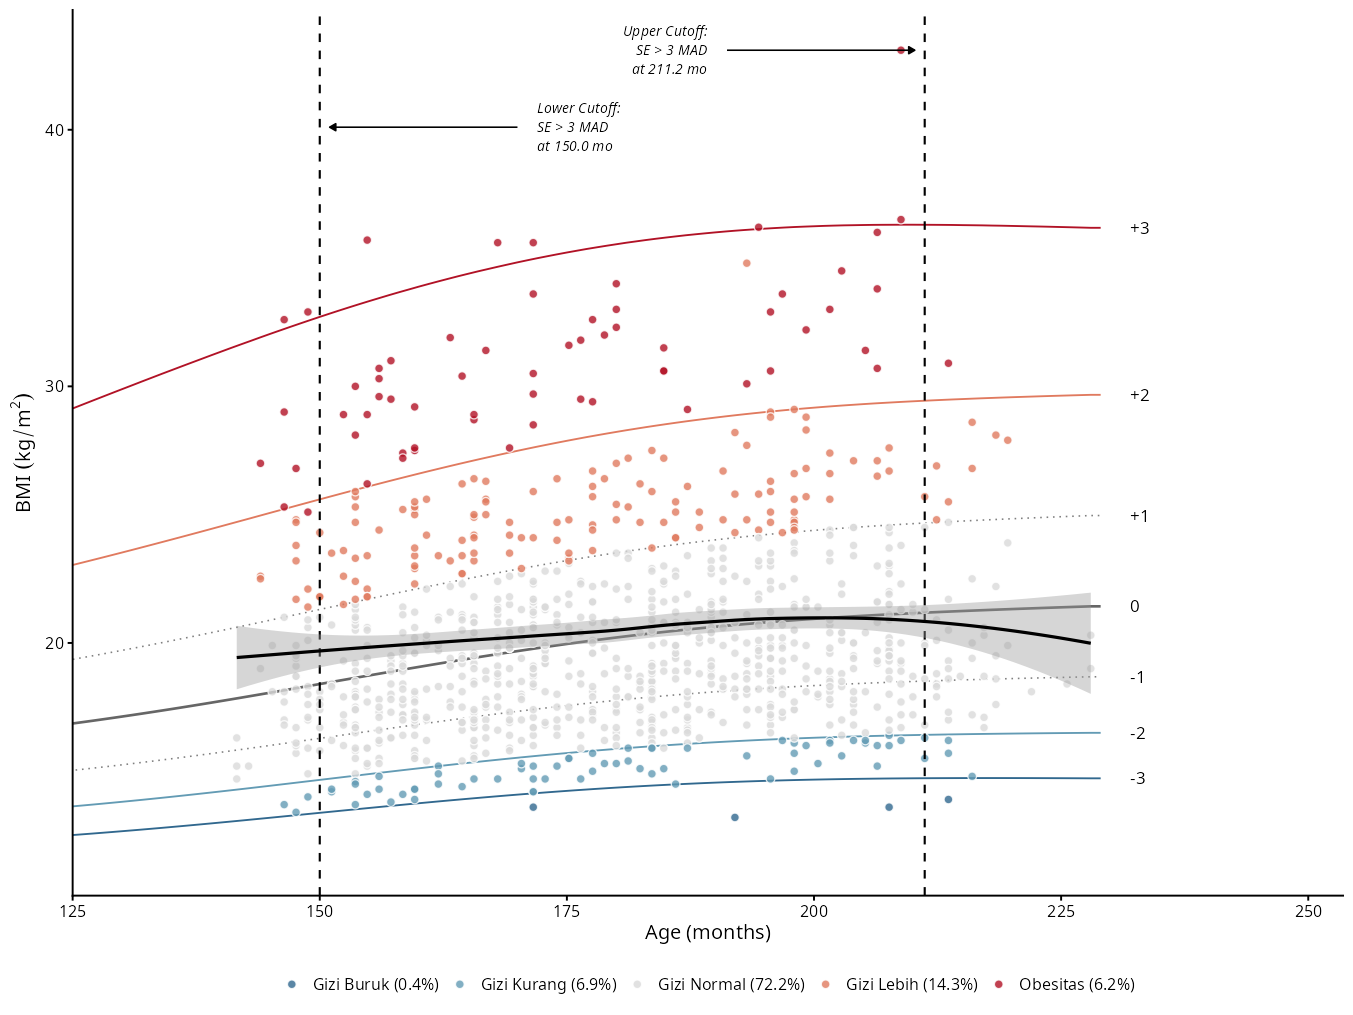

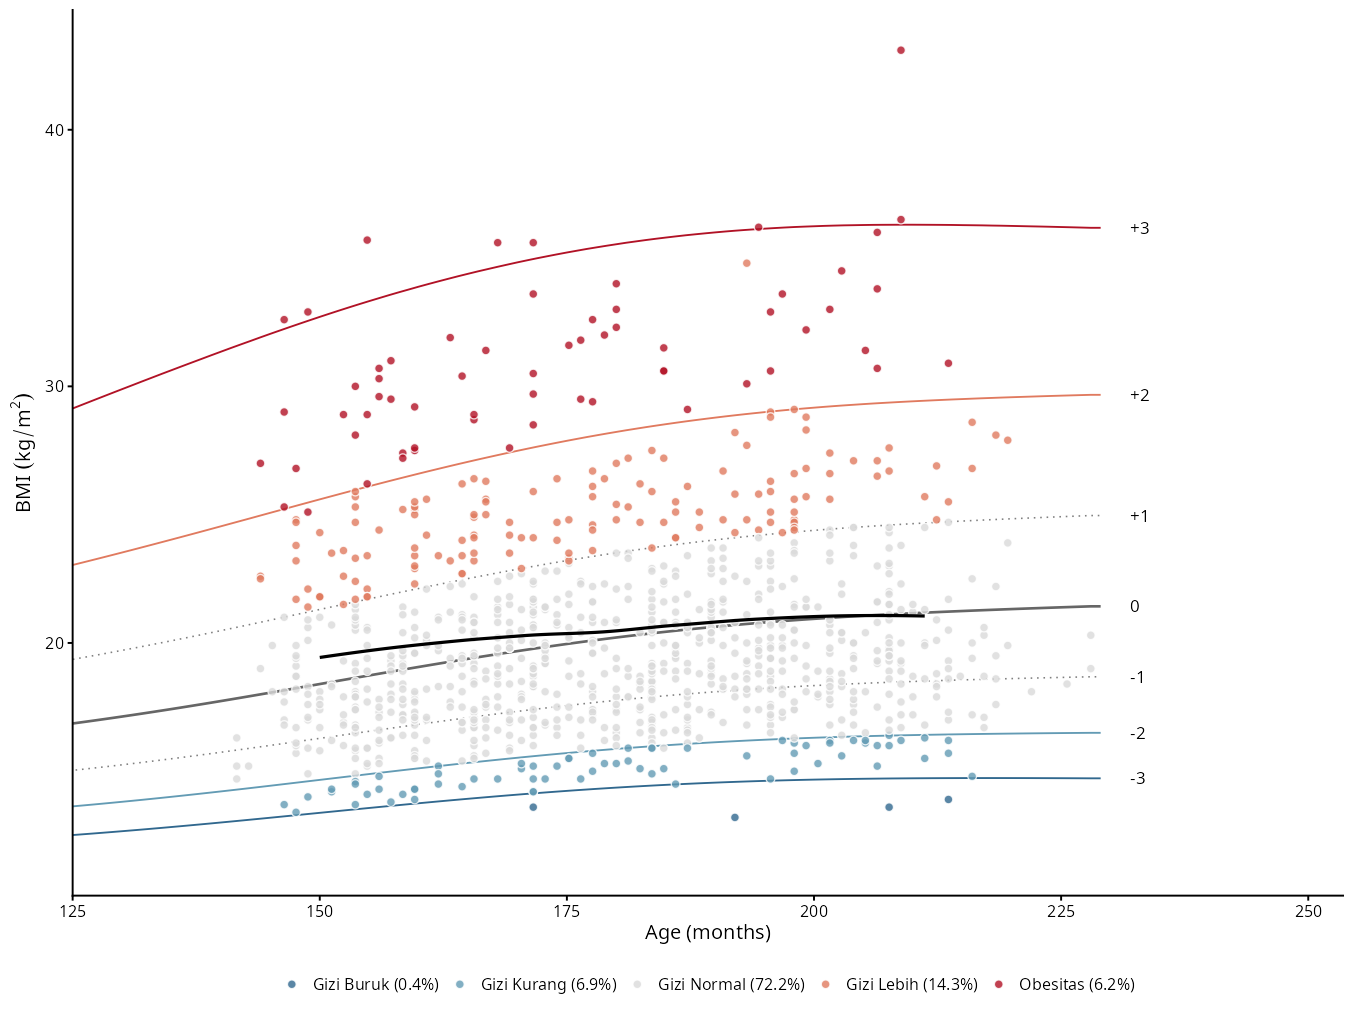

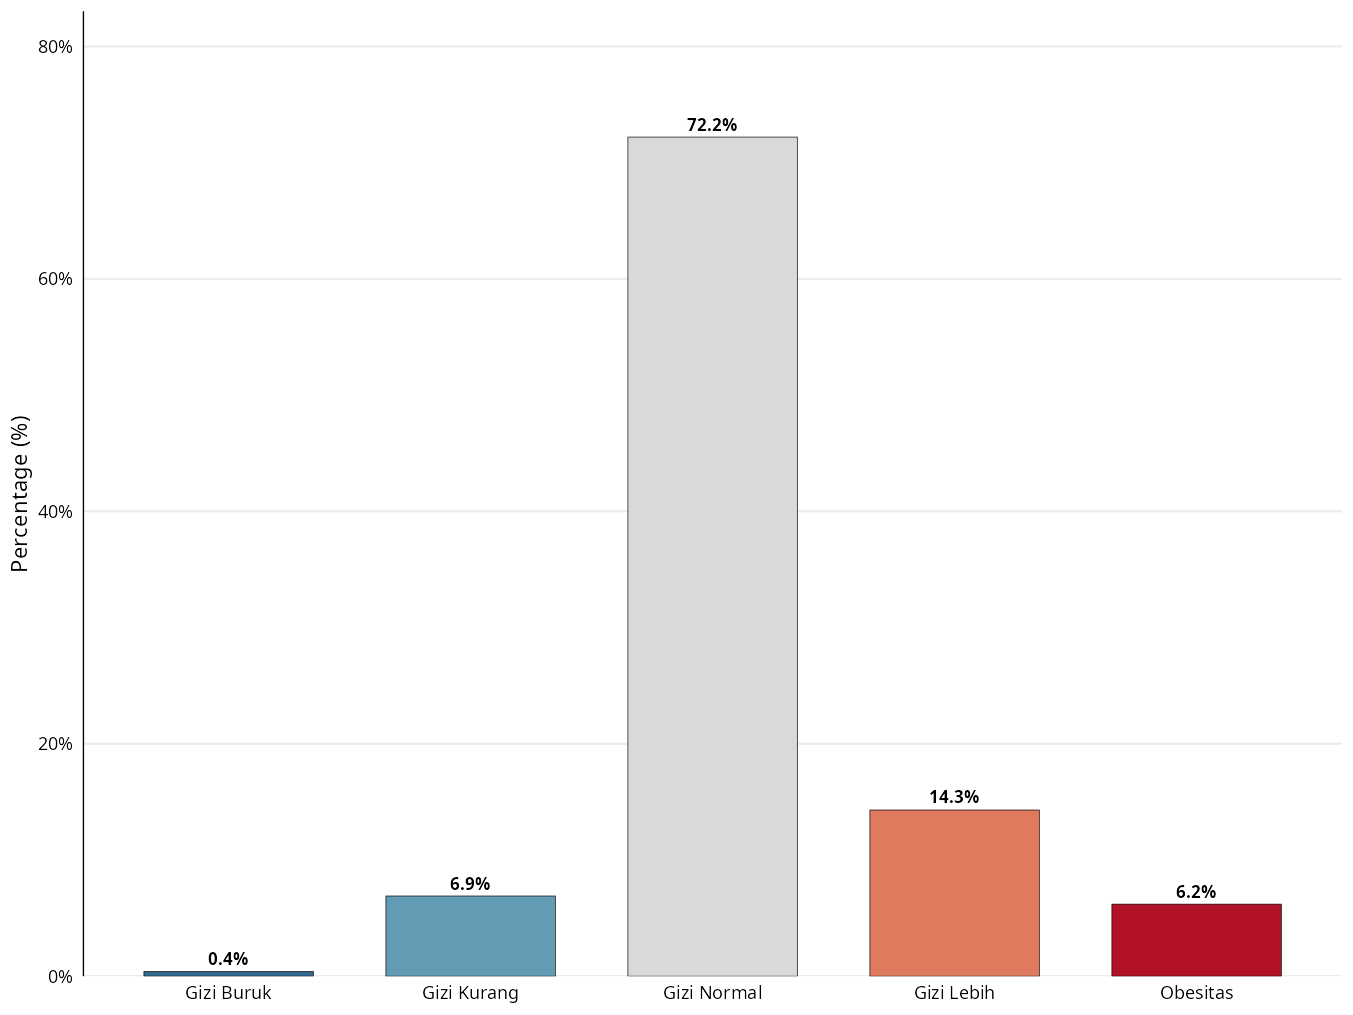

In [38]:
hasil_plot <- generate_who_charts(
  data = female_results, 
  category_col = "cat_package",
  target_sex = 2
)

# Menampilkan plot
hasil_plot$clean_plot_full
hasil_plot$clean_plot_trimmed
hasil_plot$bar_plot

# Kasus 2: Tabel data baru dimana nama kolomnya murni bmi dan umur
# hasil_plot <- generate_who_charts(
  # data = dataset_baru, 
  # category_col = "status_gizi",
  # bmi_col = "bmi",          # Tinggal oper nama kolomnya di sini
  # age_col = "umur",         # Dan di sini
  # target_sex = 2
# )

In [39]:
ggsave('plot/female_growth_chart_full.png', hasil_plot$clean_plot_full, width = 12, height = 9, dpi=1200)
ggsave('plot/female_growth_chart_trimmed.png', hasil_plot$clean_plot_trimmed, width = 12, height = 9, dpi=1200)
ggsave('plot/female_nutritional_dist_status.png', hasil_plot$bar_plot, width = 10, height = 9, dpi=1200)


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


---
## RINGKASAN STATISTIK

#### 1. Central Tendency (The "Typical" Patient)
The Mean (-0.103) and Median (-0.19) are both very close to $0$. In the WHO growth standard, $0$ represents the global median. The fact that your mean and median are hovering just below zero suggests that the "typical" participant in your cohort is slightly below the global reference median, but only marginally so. This is a very positive finding; it indicates that your cohort, on average, tracks exceptionally well with global healthy growth standards.

#### 2. Dispersion and Variation (The "Spread")
The Standard Deviation (SD) of 1.303 is arguably the most important number in this table. The WHO reference population is mathematically designed to have an SD of exactly $1.0$. Your cohort’s SD of $1.303$ tells us that your population is more heterogeneous (more spread out) than the global reference. You have a wider spectrum of BMI diversity—meaning you have a larger gap between your thinnest and heaviest participants than the WHO standard does.

#### 3. Symmetry (The Skew)
Note that your Mean (-0.103) is slightly higher (less negative) than your Median (-0.19). This difference often indicates a slight right-skew (positive skew) in the data distribution, likely caused by the presence of a few participants with high Z-scores (the "Obesitas" group) pulling the mean upward, while the median remains more resistant to these extreme outliers.

#### 4. The "Typical" Experience (Interquartile Range)
The IQR of -1.005 to 0.78 provides the most accurate view of your "middle 50%." This tells us that half of your cohort is effectively perfectly healthy, falling within the range of mild undernutrition to slight overweight, but staying comfortably away from the clinical "red zones" (below -2 or above +2).

#### 5. Clinical Extremes (Min and Max)
Minimum (-3.87): You have participants well below the -3 Z-score cutoff. Statistically, these are significant outliers representing individuals with severe acute malnutrition (Gizi Buruk). You should investigate whether these are data entry errors or legitimate clinical cases.

Maximum (3.99): You have participants nearing +4 Z-score. These individuals represent severe obesity. In a professional report, you must explicitly state that the range of this cohort spans from severe malnutrition to severe obesity, highlighting the "double burden of malnutrition" within your sample.

#### SUMMARY
The study cohort ($n=1010$) demonstrated a mean BMI-for-age Z-score of -0.103 (SD: 1.303), indicating that the population's median growth trajectory aligns closely with the WHO global reference median. However, the higher standard deviation compared to the reference population (1.303 vs. 1.0) reflects increased variability in nutritional status. The distribution is characterized by a slight positive skew, with clinical extremes ranging from severe undernutrition (Z = -3.87) to severe obesity (Z = 3.99), underscoring the presence of a double burden of malnutrition within the cohort.

### MATCHING KATEGORI ANTAR METODE

In [18]:
table(
  comparison_full$cat_manual,
  comparison_full$cat_package
)

             
              Gizi Buruk Gizi Kurang Gizi Lebih Gizi Normal Obesitas
  Gizi Buruk           4           0          0           0        0
  Gizi Kurang          0          70          0           1        0
  Gizi Lebih           0           0        144           2        0
  Gizi Normal          0           0          0         726        0
  Obesitas             0           0          0           0       63

---
# VISUALISASI DATA

In [19]:
# =====================================================
# 1. DATA
# =====================================================

plot_df <- comparison_full %>%
  filter(
    !is.na(bmi),
    !is.na(umur_bulan),
    !is.na(cat_package)
  )

# =====================================================
# 2. LMS WHO FEMALE
# =====================================================

who_lms <- anthroplus:::bfa_growth_standards %>%
  filter(sex == 2)

# =====================================================
# 3. HITUNG KURVA WHO
# =====================================================

who_curves <- who_lms %>%
  mutate(

    z_m3 = m * (1 + l*s*(-3))^(1/l),
    z_m2 = m * (1 + l*s*(-2))^(1/l),
    z_m1 = m * (1 + l*s*(-1))^(1/l),
    z_0  = m,
    z_p1 = m * (1 + l*s*(1))^(1/l),
    z_p2 = m * (1 + l*s*(2))^(1/l),
    z_p3 = m * (1 + l*s*(3))^(1/l)
  )

cat_table <- plot_df %>%
  count(cat_package) %>%
  mutate(
    pct = round(
      100 * n / sum(n),
      1
    )
  )

legend_labels <- setNames(
  paste0(
    cat_table$cat_package,
    " (",
    cat_table$pct,
    "%)"
  ),
  cat_table$cat_package
)

zone_df <- who_curves %>%
  transmute(
    age,

    zm3 = z_m3,
    zm2 = z_m2,
    zp1 = z_p1,
    zp2 = z_p2,

    ymin = 10,
    ymax = 40
  )

# Pastikan umur terurut
who_curves <- who_curves %>%
  arrange(age)

# Label di ujung kurva
label_df <- data.frame(
  age = max(who_curves$age) + 3,
  bmi = c(
    dplyr::last(who_curves$z_m3),
    dplyr::last(who_curves$z_m2),
    dplyr::last(who_curves$z_m1),
    dplyr::last(who_curves$z_0),
    dplyr::last(who_curves$z_p1),
    dplyr::last(who_curves$z_p2),
    dplyr::last(who_curves$z_p3)
  ),
  label = c("-3", "-2", "-1", "0", "+1", "+2", "+3")
)

## VISUALIZATIONS

## updated refactorization

In [44]:
prepare_growth_chart_data <- function(data, category_col, target_sex = 2) {
  
  # 1. Clean data dynamically
  plot_df <- data %>%
    filter(!is.na(bmi), !is.na(umur_bulan), !is.na(.data[[category_col]]))
  
  # 2. Extract WHO LMS Data
  who_lms <- anthroplus:::bfa_growth_standards %>%
    filter(sex == target_sex) %>% arrange(age)
  
  # 3. Calculate WHO Curves
  who_curves <- who_lms %>%
    mutate(
      z_m3 = m * (1 + l*s*(-3))^(1/l), z_m2 = m * (1 + l*s*(-2))^(1/l),
      z_m1 = m * (1 + l*s*(-1))^(1/l), z_0  = m,
      z_p1 = m * (1 + l*s*(1))^(1/l), z_p2 = m * (1 + l*s*(2))^(1/l),
      z_p3 = m * (1 + l*s*(3))^(1/l)
    )
  
  # 4. Dynamic Y-Axis Bounds
  min_bound <- floor(min(c(plot_df$bmi, who_curves$z_m3), na.rm = TRUE)) - 2
  max_bound <- ceiling(max(c(plot_df$bmi, who_curves$z_p3), na.rm = TRUE)) + 2
  
  zone_df <- who_curves %>%
    transmute(
      age, zm3 = z_m3, zm2 = z_m2, zp1 = z_p1, zp2 = z_p2,
      ymin = min_bound, ymax = max_bound
    )
  
  # 5. Dynamic Summary Table (Used for both Legends AND the Bar Chart)
  status_levels <- c("Gizi Buruk", "Gizi Kurang", "Gizi Normal", "Gizi Lebih", "Obesitas")
  cat_table <- plot_df %>%
    # count(.data[[category_col]]) %>%
    # mutate(pct = round(100 * n / sum(n), 1))
    # 2. Ubah kolom menjadi factor dengan urutan yang sudah dikunci
    mutate(!!sym(category_col) := factor(.data[[category_col]], levels = status_levels)) %>%
    # 3. Lakukan pengelompokan dan hitung ringkasan
    group_by(.data[[category_col]]) %>%
    summarise(n = n(), .groups = "drop") %>%
    # 4. Urutkan berdasarkan level factor yang baru saja kita kunci
    arrange(.data[[category_col]]) %>%
    
  # 5. Hitung persentase
  mutate(pct = round(100 * n / sum(n), 1))
  
  legend_labels <- setNames(
    paste0(cat_table[[category_col]], " (", cat_table$pct, "%)"),
    cat_table[[category_col]]
  )
  
  # 6. Curve Labels
  label_df <- data.frame(
    age = max(who_curves$age) + 3,
    bmi = c(
      dplyr::last(who_curves$z_m3), dplyr::last(who_curves$z_m2), dplyr::last(who_curves$z_m1),
      dplyr::last(who_curves$z_0),  dplyr::last(who_curves$z_p1), dplyr::last(who_curves$z_p2),
      dplyr::last(who_curves$z_p3)
    ),
    label = c("-3", "-2", "-1", "0", "+1", "+2", "+3")
  )
  
  # 7. Package and Return (Notice cat_table is now exported)
  list(
    plot_df = plot_df,
    who_curves = who_curves,
    zone_df = zone_df,
    label_df = label_df,
    legend_labels = legend_labels,
    cat_table = cat_table, 
    category_col = category_col 
  )
}

# visualization engine

## automatic LOESS

In [54]:
build_growth_charts <- function(prep_data) {
  
  # 1. Unpack the prepared data list
  plot_df <- prep_data$plot_df
  who_curves <- prep_data$who_curves
  zone_df <- prep_data$zone_df
  label_df <- prep_data$label_df
  legend_labels <- prep_data$legend_labels
  cat_table <- prep_data$cat_table
  category_col <- prep_data$category_col
  
  # Pivot curves to long format
  who_curves_long <- who_curves %>%
    pivot_longer(cols = starts_with("z_"), names_to = "curve", values_to = "value") %>%
    mutate(curve = factor(curve, levels = c("z_m3", "z_m2", "z_m1", "z_0", "z_p1", "z_p2", "z_p3")))
  
  # =====================================================================
  # --- 2. MESIN DETEKSI EKSPLOSI SE MATEMATIS (100% DINAMIS) ---
  # =====================================================================
  
  # a. Buat model LOESS yang identik dengan parameter ggplot (span = 0.9)
  # control = loess.control(surface = "direct") memastikan kalkulasi SE presisi di semua titik
  loess_model <- loess(bmi ~ umur_bulan, data = plot_df, span = 0.9, 
                       control = loess.control(surface = "direct"))
  
  # b. Buat urutan titik usia unik untuk diprediksi
  age_seq <- sort(unique(plot_df$umur_bulan))
  
  # c. Ekstrak nilai prediksi dan Standar Eror (SE)
  loess_pred <- predict(loess_model, newdata = data.frame(umur_bulan = age_seq), se = TRUE)
  se_values <- loess_pred$se.fit
  
  # d. Definisikan batas toleransi "normal" menggunakan Robust Statistics
  se_baseline <- median(se_values, na.rm = TRUE)
  se_mad <- mad(se_values, na.rm = TRUE)
  
  # Ambang batas kritis: 3 deviasi absolut dari median dasar
  se_threshold <- se_baseline + (3 * se_mad) 
  
  # e. Temukan kapan ledakan terjadi (Hanya cari di paruh kanan data)
  mid_age <- median(age_seq, na.rm = TRUE)
  explosion_points <- age_seq[age_seq > mid_age & se_values > se_threshold]
  
  # f. Tetapkan batas potong ke titik usia pertama yang mengalami ledakan
  if (length(explosion_points) > 0) {
    dynamic_cutoff <- min(explosion_points)
  } else {
    # Fallback: Jika data sangat padat sampai akhir dan SE tidak pernah meledak
    dynamic_cutoff <- max(age_seq, na.rm = TRUE) 
  }
  # =====================================================================
  
  # Mencari nilai BMI tertinggi untuk posisi anotasi
  max_bmi <- max(plot_df$bmi, na.rm = TRUE)
  
  # --- 3. MASTER COLOR PALETTE ---
  master_colors <- c(
    "Gizi Buruk" = "#31688e", "Gizi Kurang" = "#639bb4", "Gizi Normal" = "#d9d9d9",
    "Gizi Lebih" = "#e07a5f", "Obesitas" = "#b11226"
  )
  
  # --- 4. SHARED LAYERS FOR CURVE PLOTS ---
  shared_layers <- list(
    geom_point(data = plot_df, aes(umur_bulan, bmi, fill = .data[[category_col]]), shape = 21, color = "white", alpha = 0.8, size = 2.8),
    geom_text(data = label_df, aes(age, bmi, label = label), hjust = 0, size = 5),
    scale_fill_manual(values = master_colors, labels = legend_labels),
    coord_cartesian(xlim = c(min(who_curves$age), max(who_curves$age) + 12)),
    scale_x_continuous(expand = expansion(mult = c(0, 0.08))),
    theme_classic(base_size = 16),
    theme(legend.position = "bottom", legend.title = element_blank()),
    labs(subtitle = NULL, x = "Age (months)", y = expression(BMI~(kg/m^2)))
  )
  
  # --- 5. PENGATURAN KURVA WHO ---
  clean_colors <- c("z_m3"="#31688e", "z_m2"="#639bb4", "z_m1"="grey50", "z_0"="grey40", "z_p1"="grey50", "z_p2"="#e07a5f", "z_p3"="#b11226")
  clean_lines  <- c("z_m3"="solid", "z_m2"="solid", "z_m1"="dotted", "z_0"="solid", "z_p1"="dotted", "z_p2"="solid", "z_p3"="solid")
  clean_sizes  <- c("z_m3"=0.7, "z_m2"=0.7, "z_m1"=0.6, "z_0"=1.0, "z_p1"=0.6, "z_p2"=0.7, "z_p3"=0.7)
  
  base_clean_plot <- ggplot() +
    geom_line(data = who_curves_long, aes(age, value, group = curve, color = curve, linetype = curve, linewidth = curve)) +
    scale_color_manual(values = clean_colors) + scale_linetype_manual(values = clean_lines) + scale_linewidth_manual(values = clean_sizes) +
    guides(color = "none", linetype = "none", linewidth = "none") +
    shared_layers

  # --- PLOT 1: FULL LOESS (PEMBUKTIAN MATEMATIS EKSPLOSI SE) ---
  plot_clean_full <- base_clean_plot +
    geom_vline(xintercept = dynamic_cutoff, linetype = "dashed", color = "black", linewidth = 0.8) +
    # annotate("segment", x = dynamic_cutoff - 25, xend = dynamic_cutoff - 1, 
    #          y = max_bmi, yend = max_bmi, 
    #          arrow = arrow(length = unit(0.25, "cm"), type = "closed"), 
    #          color = "black", linewidth = 0.8) +
    # annotate("text", x = dynamic_cutoff - 27, y = max_bmi, 
    #          label = paste0("Methodological Threshold: Critical Precision Loss at ", round(dynamic_cutoff, 1), " mo"), 
    #          hjust = 1, size = 4.5, fontface = "bold.italic", lineheight = 0.9) +
    geom_smooth(data = plot_df, aes(umur_bulan, bmi), method = "loess", span = 0.9, 
                se = TRUE, fill = "grey60", alpha = 0.4, linewidth = 1.2, color = "black")
  
  # --- PLOT 2: TRIMMED LOESS (HASIL AKADEMIS BERSIH) ---
  plot_clean_trimmed <- base_clean_plot +
    geom_smooth(data = plot_df %>% filter(umur_bulan <= dynamic_cutoff), 
                aes(umur_bulan, bmi), method = "loess", span = 0.9, 
                se = FALSE, linewidth = 1.2, color = "black")

  # --- PLOT 3: ZONE PLOT ---
  zone_lines <- c("z_m3"="dashed", "z_m2"="dashed", "z_m1"="dotted", "z_0"="solid", "z_p1"="dotted", "z_p2"="dashed", "z_p3"="dashed")
  zone_sizes <- c("z_m3"=0.6, "z_m2"=0.6, "z_m1"=0.6, "z_0"=1.0, "z_p1"=0.6, "z_p2"=0.6, "z_p3"=0.6)
  
  plot_zone <- ggplot() +
    geom_ribbon(data = zone_df, aes(age, ymin = ymin, ymax = zm3), fill = "#31688e", alpha = 0.05) +
    geom_ribbon(data = zone_df, aes(age, ymin = zm3, ymax = zm2), fill = "#639bb4", alpha = 0.05) +
    geom_ribbon(data = zone_df, aes(age, ymin = zm2, ymax = zp1), fill = "#d9d9d9", alpha = 0.08) +
    geom_ribbon(data = zone_df, aes(age, ymin = zp1, ymax = zp2), fill = "#e07a5f", alpha = 0.05) +
    geom_ribbon(data = zone_df, aes(age, ymin = zp2, ymax = ymax), fill = "#b11226", alpha = 0.05) +
    geom_line(data = who_curves_long, aes(age, value, group = curve, linetype = curve, linewidth = curve)) +
    scale_linetype_manual(values = zone_lines) + scale_linewidth_manual(values = zone_sizes) +
    guides(linetype = "none", linewidth = "none") +
    shared_layers +
    geom_smooth(data = plot_df %>% filter(umur_bulan <= dynamic_cutoff), aes(umur_bulan, bmi), method = "loess", span = 0.9, se = FALSE, linewidth = 1.2, color = "black") +
    labs(title = "WHO BMI-for-Age Growth Chart")
    
  # --- PLOT 4: BAR PLOT DISTRIBUTION ---
  urutan_asli <- as.character(unique(cat_table[[category_col]]))

  plot_dist <- ggplot(cat_table, aes(x = .data[[category_col]], y = pct, fill = .data[[category_col]])) +
    geom_col(width = 0.7, color = "black", linewidth = 0.25) +
    geom_text(aes(label = sprintf("%.1f%%", pct)), vjust = -0.5, size = 5, fontface = "bold") +
    scale_fill_manual(values = master_colors) +
    scale_x_discrete(limits=urutan_asli) +
    scale_y_continuous(labels = scales::label_percent(scale = 1), expand = expansion(mult = c(0, 0.15))) +
    theme_minimal(base_size = 18) +
    theme(
      legend.position = "none",
      panel.grid.major.x = element_blank(),
      panel.grid.minor = element_blank(),
      axis.text = element_text(color = "black"),
      axis.line.y = element_line(color = "black", linewidth = 0.5)
    ) +
    labs(title = NULL, x = NULL, y = "Percentage (%)")
  
  list(
    clean_plot_full = plot_clean_full, 
    clean_plot_trimmed = plot_clean_trimmed, 
    zone_plot = plot_zone, 
    bar_plot = plot_dist,
    calculated_cutoff = dynamic_cutoff  # Mengembalikan angka agar Anda bisa melihatnya
  )
}

## execution 

`geom_smooth()` using formula = 'y ~ x'


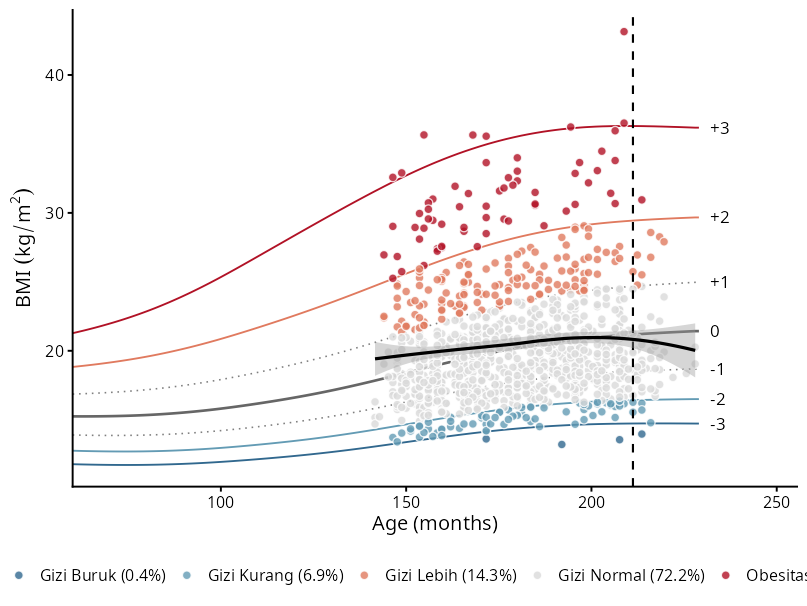

`geom_smooth()` using formula = 'y ~ x'


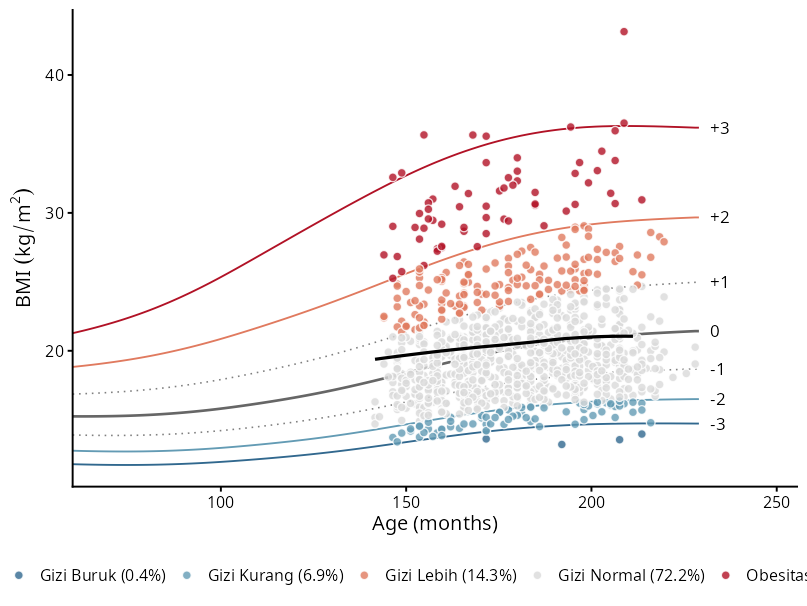

In [55]:
# STEP 1: Feed the raw data and parameters into the Data Engine
plot_data_prepared <- prepare_growth_chart_data(
  data = comparison_full, 
  category_col = "cat_package", 
  target_sex = 2
)

# STEP 2: Feed the prepared list into the Visualization Engine
charts <- build_growth_charts(prep_data = plot_data_prepared)

# STEP 3: Print whichever plot you want to inspect
print(charts$clean_plot_full)
print(charts$clean_plot_trimmed)
# print(charts$bar_plot)

In [56]:
ggsave('plot/growth_chart_full2.png', charts$clean_plot_full, width = 12, height = 8, units = "in", dpi = 1200)
# ggsave('plot/growth_chart_trimmed.png', charts$clean_plot_trimmed, width = 12, height = 8, units = "in", dpi = 1200)

`geom_smooth()` using formula = 'y ~ x'


## mengapa pemotongan garis LOESS PENTING

---

### 1. Landasan Matematis: Mengapa SE "Meledak"?

Untuk memahami mengapa *Standard Error* (SE) meledak, kita harus melihat bagaimana model regresi lokal (seperti LOESS) bekerja. Tidak seperti regresi linear global (di mana seluruh data digunakan untuk membuat satu garis), LOESS bekerja secara lokal di setiap titik $x$ (usia).

Model ini mengestimasi nilai $y$ (BMI) dengan memberikan bobot lebih besar pada data yang dekat dengan titik $x$ dan bobot lebih kecil pada data yang jauh. Varians dari prediksi tersebut ($\text{Var}(\hat{y}|x)$) dinyatakan sebagai:

$$\text{Var}(\hat{y}|x) \approx \sigma^2 \cdot \sum_{i=1}^{n} w_i(x)^2$$

Di mana:

* $\sigma^2$: Adalah varians dari *noise* (ketidakpastian) data mentah.
* $w_i(x)$: Adalah bobot yang diberikan model untuk setiap titik data $i$ di sekitar usia $x$.

Dalam penyederhanaan statistik, ini berbanding terbalik dengan **kerapatan sampel lokal** ($n_x$):

$$\text{Var}(\hat{y}|x) \propto \frac{\sigma^2}{n_x}$$

**Artinya:** Jika jumlah sampel di sekitar usia tersebut ($n_x$) mendekati angka nol, maka penyebutnya menjadi sangat kecil. Secara matematis, saat penyebut mendekati nol, nilai varians (dan akibatnya *Standard Error* $\sqrt{\text{Var}}$) akan **meledak menuju tak terhingga ($\infty$)**.

### 2. Terjemahan ke Logika (Analogi "Balok Keseimbangan")

Bayangkan regresi LOESS adalah seorang atlet sirkus yang sedang berjalan di atas balok keseimbangan (garis tren).

* **Di tengah grafik (Data Padat):** Atlet tersebut didukung oleh banyak orang (banyak data). Jika dia sedikit goyah, orang-orang di sekelilingnya akan menstabilkan posisinya. Ini adalah kondisi di mana $n_x$ besar, SE kecil, dan kita memiliki keyakinan tinggi.
* **Di ujung grafik (Data Menipis):** Atlet tersebut berdiri di ujung balok yang menggantung. Dia tidak lagi didukung oleh siapa pun. Jika dia melakukan satu gerakan kecil saja (ada satu *outlier* data), dia akan langsung jatuh ke arah tersebut karena tidak ada data lain yang menyeimbangkannya.

**Logika statistiknya:** Ketika $n_x$ kecil, model "kehilangan jangkar". Jika ada satu partisipan dengan BMI sangat rendah di usia 218 bulan, model akan "percaya" bahwa seluruh populasi memiliki BMI rendah, padahal itu hanya perilaku satu orang. Itulah mengapa SE meledak: model secara jujur memberi tahu kita, *"Saya tidak tahu apa yang terjadi di sini, varians prediksi saya sangat besar!"*

### 3. Rasionalisasi: Mengapa Harus Dipotong?

Pemotongan berdasarkan Eksplosi SE ini bukan sekadar urusan estetika grafik, melainkan **kewajiban etika ilmiah**. Berikut adalah alasan utamanya:

1. **Menghindari "Halusinasi Statistik":** Tanpa pemotongan, garis tren akan terus ditarik hingga titik data terakhir. Jika data terakhir adalah *outlier*, garis tersebut akan mengikuti *outlier* tersebut. Pembaca akan melihat grafik yang menukik tajam dan menyimpulkan secara klinis: *"Oh, ternyata remaja akhir mengalami penurunan berat badan drastis."* Padahal, itu adalah kesimpulan yang salah (palsu). Pemotongan mencegah kita menyebarkan informasi medis yang menyesatkan.
2. **Menjaga *Confidence Interval* (Interval Kepercayaan):** Pita SE yang melebar tajam adalah sinyal bahwa model sudah kehilangan validitasnya. Dengan memotong garis tepat sebelum pita tersebut meledak, kita secara visual menunjukkan: *"Di sinilah batas di mana data kita cukup representatif untuk membuat inferensi."*
3. **Transparansi vs. Interpretasi:**
* **Data Mentah (Scatter Plot):** Tetap kita tampilkan apa adanya. Ini menunjukkan kejujuran data (tidak ada data yang dibuang/dihapus).
* **Garis Tren (LOESS):** Kita batasi. Ini menunjukkan batas interpretasi (kita tidak membuat klaim tren di area di mana data tidak memadai).



### Kesimpulan untuk Laporan Anda

Anda bisa menuliskan kalimat ini di dalam laporan:

> "Kami menerapkan batas potong metodologis berdasarkan deteksi otomatis eksplosi *Standard Error* (SE). Secara matematis, varians estimasi regresi lokal berbanding terbalik dengan kerapatan sampel lokal ($n_x$). Ketika $n_x$ menipis, ketidakpastian model ($SE$) meningkat secara eksponensial. Kami memilih untuk memotong kurva tren tepat pada ambang batas di mana $SE$ melampaui batas kritis ($Median + 3 \times MAD$), guna memastikan bahwa visualisasi tren yang disajikan hanya merepresentasikan area di mana populasi sampel memiliki representasi statistik yang valid dan stabil."

Apakah penjelasan ini memberikan dasar argumen yang cukup kuat untuk mempertahankan metodologi Anda saat sidang atau penelaahan jurnal nanti?

### Comprehensive Clinical Findings
Your graphic provides two layers of insight: the static distribution of the cohort, and the longitudinal trajectory of their growth.
#### 1. The Population Distribution
The majority of the female participants are growing appropriately according to global standards. Specifically, 72.2% of the cohort falls within the "Gizi Normal" bounds (between the $-2$ and $+1$ WHO reference curves). This indicates a strong baseline of healthy development in the surveyed population.
#### 2. The Double Burden of Malnutrition
When we look outside the normal range, the data reveals a stark clinical imbalance. We can group the extreme categories to see the systemic nutritional shift:
| Nutritional Status | Component Categories | Combined Prevalence |
| :--- | :--- | :--- |
| Undernutrition | Gizi Buruk (0.4%) + Gizi Kurang (6.9%) | 7.3% |
| Overnutrition | Gizi Lebih (14.3%) + Obesitas (6.2%) | 20.5% |

The prevalence of overnutrition is nearly three times higher than the prevalence of undernutrition. This rightward skew is a classic hallmark of the "nutritional transition," where populations moving toward modern diets and sedentary lifestyles rapidly develop higher rates of obesity, even while trace amounts of severe undernourishment remain.

#### 3. The Cohort Trajectory
The thick black LOESS line represents the median path of your specific sample. Between 140 and 190 months, your cohort tracks slightly below the WHO reference median ($Z = 0$, the solid grey line). However, the trajectory runs perfectly parallel to the global standard. This means that while your cohort might have a slightly lower baseline BMI than the exact global average, their velocity of growth is entirely normal and healthy.

### The Mechanics of the LOESS 0.98 Trim
In your previous iteration, the LOESS line at the extreme right edge of the chart took a sudden, unnatural nosedive. We fixed this by applying a 98% quantile trim specifically to the line calculation. Here is the mathematical rationale behind that decision.

#### How LOESS Works
LOESS (Locally Estimated Scatterplot Smoothing) calculates the path of a line by looking at a "window" of nearby data points. To figure out where the line should be at 150 months, the algorithm looks at the dense cluster of dots immediately surrounding 150 months, calculates a localized average, and connects the dots.

#### The Problem: The Edge Effect
Look at the right side of your chart, past 210 months. The data points thin out drastically. There are very few participants in that older age bracket. When the LOESS algorithm reaches this sparse area, it no longer has a dense cluster of data to anchor it. Because the sample size locally is so small, a single outlier (like the lone blue dot sitting near the $-3$ curve at 215 months) exerts massive gravitational pull on the math, dragging the entire trendline downward.

The Rationale for the Trim
If we plot that sudden nosedive, we are lying to the viewer. A severe drop in the line implies that the entire population suddenly loses massive amounts of weight at 215 months. In reality, we just ran out of data.

To solve this, we applied this code to the geom_smooth layer:
`filter(umur_bulan <= quantile(umur_bulan, 0.98, na.rm = TRUE))`

#### What this achieves:
- **Isolates the Signal**: It tells the algorithm to calculate the trendline using only the densest 98% of the participants, entirely ignoring the sparse 2% on the extreme right edge.
- **Maintains Data Integrity**: We only trimmed the data inside the trendline calculation. The actual scatter points (the dots) for those older participants are still plotted on the canvas
- **Stops the Illusion**: By terminating the line while the data is still dense, the model admits where its confidence ends, rather than wild-guessing in a sparse zone.

In [ ]:
ggsave('plot/growth_chart_updated.png', charts$clean_plot, width = 10, height = 8, unit="in", dpi=1200)

`geom_smooth()` using formula = 'y ~ x'
